# Telco Customer Churn — Financial Analysis

## Objective

The goal of this notebook is to estimate the financial impact of customer churn using the Telco Customer Churn dataset.

This analysis focuses on the following business questions:

- How much monthly revenue is associated with churned customers?
- What percentage of revenue is at risk due to churn?
- Which customer segments generate the greatest revenue loss?
- What is the estimated annual revenue impact of churn?
- Which segments should be prioritized from a financial perspective?

The purpose of this notebook is to translate churn behavior into measurable business and financial impact.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Load Dataset

We load the dataset and prepare it for financial analysis.

In [2]:
df = pd.read_csv("../data/telco_churn_cleaned.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag,TenureGroup,MonthlyChargesGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12 months,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48 months,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12 months,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48 months,Medium
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12 months,High


## Feature Engineering

To support financial calculations, we create:

- `Churn_Flag`: binary churn variable
- `TenureGroup`: grouped tenure ranges
- `MonthlyChargesGroup`: grouped monthly charge levels

In [3]:
df["Churn_Flag"] = df["Churn"].map({"Yes": 1, "No": 0})

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"],
    include_lowest=True
)

df["MonthlyChargesGroup"] = pd.qcut(
    df["MonthlyCharges"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag,TenureGroup,MonthlyChargesGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12 months,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48 months,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12 months,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48 months,Medium
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12 months,High


## Split Active and Churned Customers

We separate churned customers from active customers in order to compare revenue contribution and revenue loss.

In [4]:
churned = df[df["Churn"] == "Yes"].copy()
active = df[df["Churn"] == "No"].copy()

print("Active customers:", len(active))
print("Churned customers:", len(churned))

Active customers: 5163
Churned customers: 1869


## Revenue Overview

We start by calculating the core financial KPIs.

In [5]:
total_monthly_revenue = df["MonthlyCharges"].sum()
active_monthly_revenue = active["MonthlyCharges"].sum()
lost_monthly_revenue = churned["MonthlyCharges"].sum()

lost_revenue_pct = (lost_monthly_revenue / total_monthly_revenue) * 100
annualized_lost_revenue = lost_monthly_revenue * 12

print(f"Total monthly revenue: ${total_monthly_revenue:,.2f}")
print(f"Active customer monthly revenue: ${active_monthly_revenue:,.2f}")
print(f"Lost monthly revenue from churned customers: ${lost_monthly_revenue:,.2f}")
print(f"Revenue at risk (% of total monthly revenue): {lost_revenue_pct:.2f}%")
print(f"Estimated annualized lost revenue: ${annualized_lost_revenue:,.2f}")

Total monthly revenue: $455,661.00
Active customer monthly revenue: $316,530.15
Lost monthly revenue from churned customers: $139,130.85
Revenue at risk (% of total monthly revenue): 30.53%
Estimated annualized lost revenue: $1,669,570.20


These KPIs show the direct financial exposure created by churn.

Even if churn is often discussed as a customer behavior problem, it also represents a measurable and recurring revenue risk for the business.

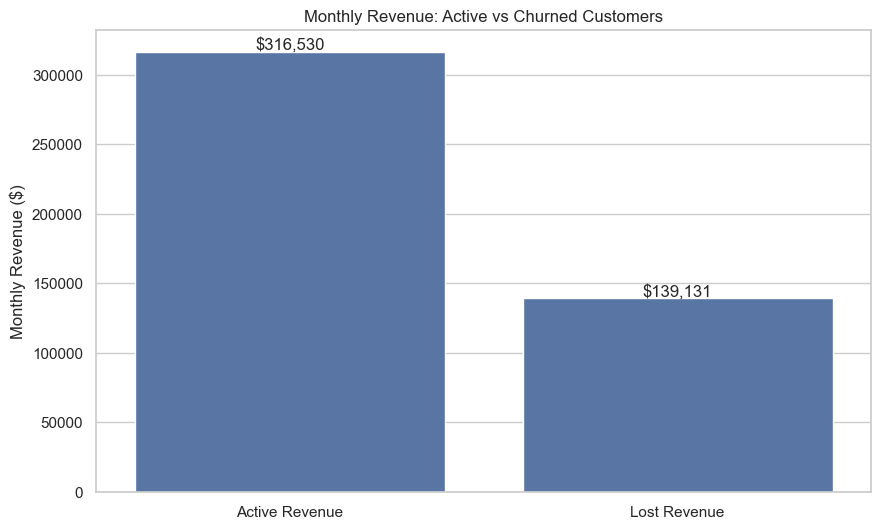

In [6]:
revenue_summary = pd.DataFrame({
    "Revenue Type": ["Active Revenue", "Lost Revenue"],
    "Monthly Revenue": [active_monthly_revenue, lost_monthly_revenue]
})

ax = sns.barplot(data=revenue_summary, x="Revenue Type", y="Monthly Revenue")
plt.title("Monthly Revenue: Active vs Churned Customers")
plt.xlabel("")
plt.ylabel("Monthly Revenue ($)")

for i, value in enumerate(revenue_summary["Monthly Revenue"]):
    plt.text(i, value + 2000, f"${value:,.0f}", ha="center")

plt.show()

The chart compares monthly revenue generated by active customers with the monthly revenue associated with churned customers.

The lost portion represents revenue the company is no longer collecting because those customers left.

## Average Revenue per Customer

We compare the average monthly charges of churned and active customers to understand whether churn is concentrated among lower-value or higher-value customers.

In [7]:
avg_monthly_charge_active = active["MonthlyCharges"].mean()
avg_monthly_charge_churned = churned["MonthlyCharges"].mean()

print(f"Average monthly charge - Active customers: ${avg_monthly_charge_active:,.2f}")
print(f"Average monthly charge - Churned customers: ${avg_monthly_charge_churned:,.2f}")

Average monthly charge - Active customers: $61.31
Average monthly charge - Churned customers: $74.44


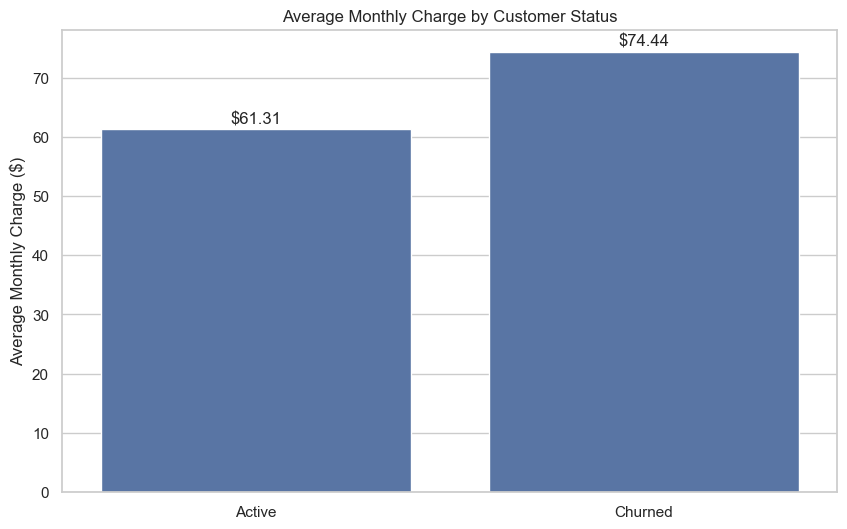

In [8]:
avg_revenue_comparison = pd.DataFrame({
    "Customer Status": ["Active", "Churned"],
    "Average Monthly Charge": [avg_monthly_charge_active, avg_monthly_charge_churned]
})

ax = sns.barplot(data=avg_revenue_comparison, x="Customer Status", y="Average Monthly Charge")
plt.title("Average Monthly Charge by Customer Status")
plt.xlabel("")
plt.ylabel("Average Monthly Charge ($)")

for i, value in enumerate(avg_revenue_comparison["Average Monthly Charge"]):
    plt.text(i, value + 1, f"${value:.2f}", ha="center")

plt.show()

If churned customers have a higher average monthly charge than active customers, then churn is financially more damaging because the company is losing relatively higher-value accounts.

## Revenue by Contract Type

We now analyze how monthly revenue is distributed across contract categories.

In [9]:
revenue_by_contract = (
    df.groupby("Contract")["MonthlyCharges"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_contract

Contract
Month-to-month    257294.15
Two year          102569.95
One year           95796.90
Name: MonthlyCharges, dtype: float64

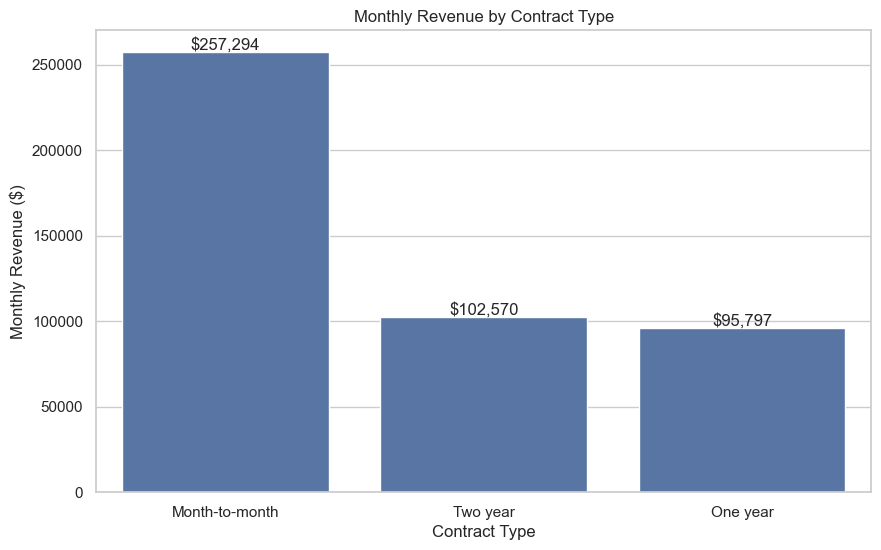

In [10]:
ax = sns.barplot(
    x=revenue_by_contract.index,
    y=revenue_by_contract.values
)

plt.title("Monthly Revenue by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Monthly Revenue ($)")

for i, value in enumerate(revenue_by_contract.values):
    plt.text(i, value + 1500, f"${value:,.0f}", ha="center")

plt.show()

This view shows which contract segments generate the most monthly revenue overall.

A segment can be financially important either because it has many customers or because it generates high average charges.

## Lost Revenue by Contract Type

Next, we isolate churned customers only and examine which contract categories contribute the most lost monthly revenue.

In [11]:
lost_revenue_by_contract = (
    churned.groupby("Contract")["MonthlyCharges"]
    .sum()
    .sort_values(ascending=False)
)

lost_revenue_by_contract

Contract
Month-to-month    120847.10
One year           14118.45
Two year            4165.30
Name: MonthlyCharges, dtype: float64

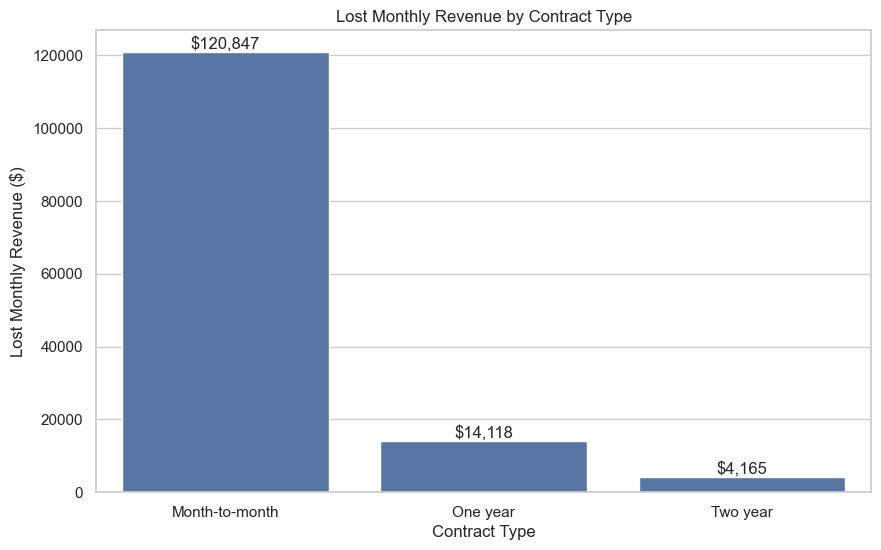

In [12]:
ax = sns.barplot(
    x=lost_revenue_by_contract.index,
    y=lost_revenue_by_contract.values
)

plt.title("Lost Monthly Revenue by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Lost Monthly Revenue ($)")

for i, value in enumerate(lost_revenue_by_contract.values):
    plt.text(i, value + 1000, f"${value:,.0f}", ha="center")

plt.show()

If month-to-month customers account for the largest share of lost revenue, this confirms that the company is not only losing more customers in this segment, but also losing significant revenue concentration there.

## Revenue Loss Rate by Contract Type

Absolute lost revenue is important, but it is also useful to measure how much of each segment’s total revenue is being lost.

In [13]:
contract_total_revenue = df.groupby("Contract")["MonthlyCharges"].sum()
contract_lost_revenue = churned.groupby("Contract")["MonthlyCharges"].sum()

contract_loss_rate = ((contract_lost_revenue / contract_total_revenue) * 100).sort_values(ascending=False)
contract_loss_rate

Contract
Month-to-month    46.968460
One year          14.737899
Two year           4.060936
Name: MonthlyCharges, dtype: float64

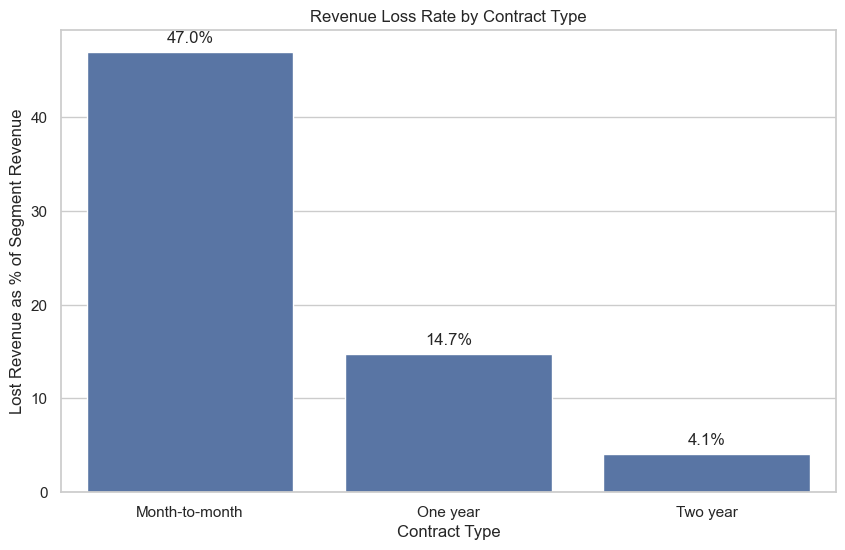

In [14]:
ax = sns.barplot(
    x=contract_loss_rate.index,
    y=contract_loss_rate.values
)

plt.title("Revenue Loss Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Lost Revenue as % of Segment Revenue")

for i, value in enumerate(contract_loss_rate.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

This metric is especially useful because it shows the share of each contract segment’s own revenue that is disappearing due to churn.

It gives a better sense of segment-level financial vulnerability.

## Revenue by Payment Method

Payment behavior can also influence financial performance.

We examine which payment methods contribute the most revenue overall.

In [15]:
revenue_by_payment = (
    df.groupby("PaymentMethod")["MonthlyCharges"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_payment

PaymentMethod
Electronic check             180345.0
Bank transfer (automatic)    103631.0
Credit card (automatic)      101175.8
Mailed check                  70509.2
Name: MonthlyCharges, dtype: float64

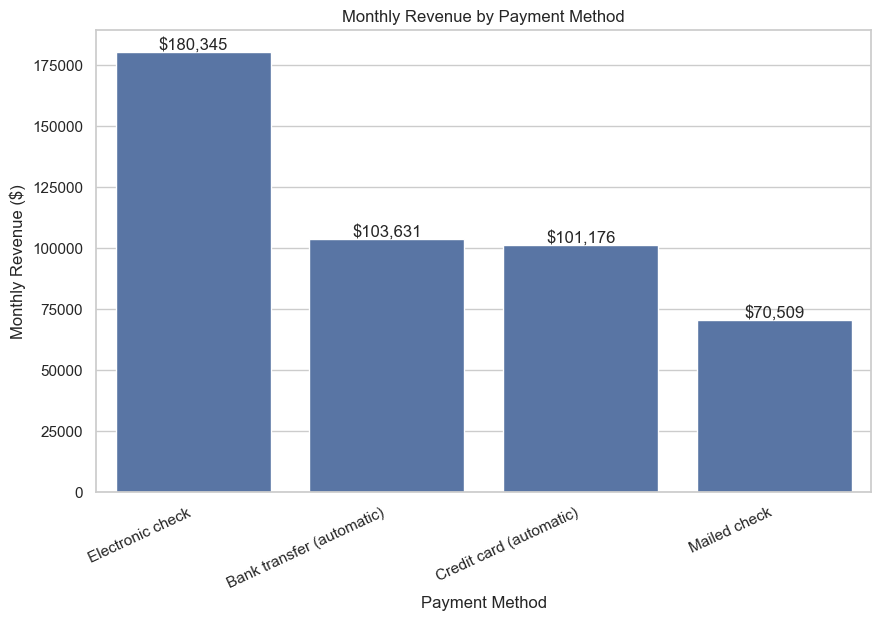

In [16]:
ax = sns.barplot(
    x=revenue_by_payment.index,
    y=revenue_by_payment.values
)

plt.title("Monthly Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Monthly Revenue ($)")
plt.xticks(rotation=25, ha="right")

for i, value in enumerate(revenue_by_payment.values):
    plt.text(i, value + 1200, f"${value:,.0f}", ha="center")

plt.show()

This chart shows which payment method groups are most important from a revenue standpoint.

## Lost Revenue by Payment Method

We now focus on churned customers and examine lost monthly revenue by payment method.

In [17]:
lost_revenue_by_payment = (
    churned.groupby("PaymentMethod")["MonthlyCharges"]
    .sum()
    .sort_values(ascending=False)
)

lost_revenue_by_payment

PaymentMethod
Electronic check             84288.75
Bank transfer (automatic)    20091.90
Credit card (automatic)      17946.60
Mailed check                 16803.60
Name: MonthlyCharges, dtype: float64

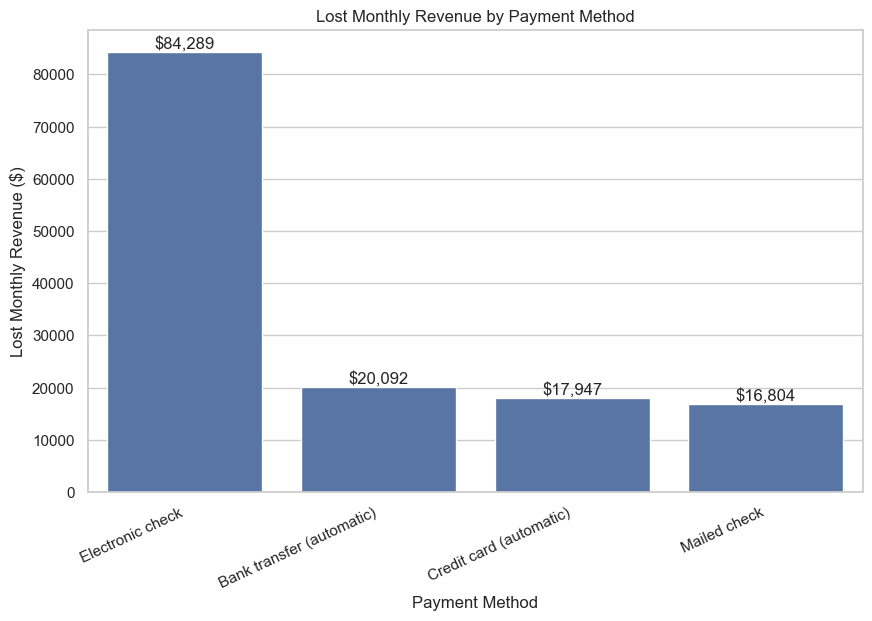

In [18]:
ax = sns.barplot(
    x=lost_revenue_by_payment.index,
    y=lost_revenue_by_payment.values
)

plt.title("Lost Monthly Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Lost Monthly Revenue ($)")
plt.xticks(rotation=25, ha="right")

for i, value in enumerate(lost_revenue_by_payment.values):
    plt.text(i, value + 800, f"${value:,.0f}", ha="center")

plt.show()

If electronic check customers generate the most lost revenue, this suggests that this billing segment is not only behaviorally risky but also financially costly.

## Revenue by Tenure Group

We now analyze revenue by customer tenure group to understand where the company earns the most and where it loses the most.

In [19]:
revenue_by_tenure = (
    df.groupby("TenureGroup", observed=False)["MonthlyCharges"]
    .sum()
    .reindex(["0-12 months", "13-24 months", "25-48 months", "49-72 months"])
)

revenue_by_tenure

TenureGroup
0-12 months     122174.15
13-24 months     62829.85
25-48 months    105093.30
49-72 months    165563.70
Name: MonthlyCharges, dtype: float64

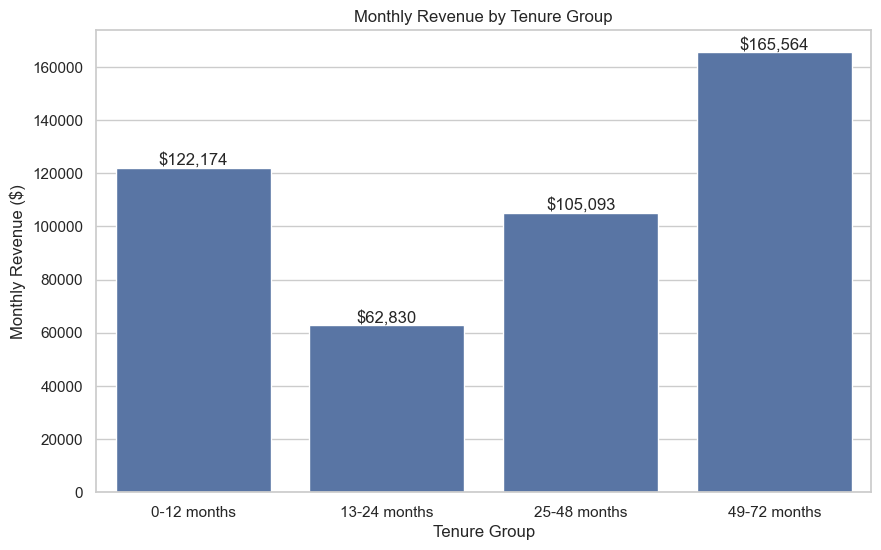

In [20]:
ax = sns.barplot(
    x=revenue_by_tenure.index,
    y=revenue_by_tenure.values
)

plt.title("Monthly Revenue by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Monthly Revenue ($)")

for i, value in enumerate(revenue_by_tenure.values):
    plt.text(i, value + 1200, f"${value:,.0f}", ha="center")

plt.show()

This chart shows which customer lifecycle stages contribute most to current monthly revenue.

## Lost Revenue by Tenure Group

We isolate churned customers to see which tenure groups drive the greatest monthly revenue loss.

In [21]:
lost_revenue_by_tenure = (
    churned.groupby("TenureGroup", observed=False)["MonthlyCharges"]
    .sum()
    .reindex(["0-12 months", "13-24 months", "25-48 months", "49-72 months"])
)

lost_revenue_by_tenure

TenureGroup
0-12 months     68954.25
13-24 months    23081.65
25-48 months    27462.50
49-72 months    19632.45
Name: MonthlyCharges, dtype: float64

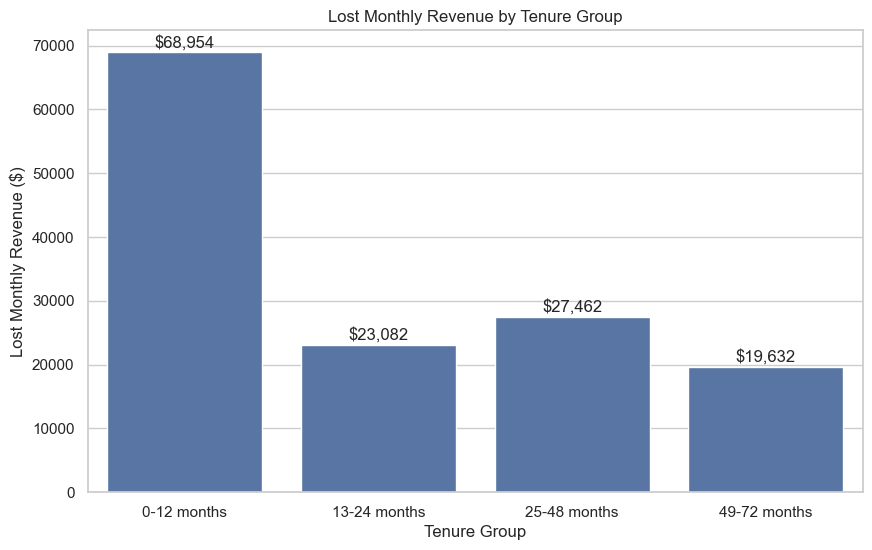

In [22]:
ax = sns.barplot(
    x=lost_revenue_by_tenure.index,
    y=lost_revenue_by_tenure.values
)

plt.title("Lost Monthly Revenue by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Lost Monthly Revenue ($)")

for i, value in enumerate(lost_revenue_by_tenure.values):
    plt.text(i, value + 800, f"${value:,.0f}", ha="center")

plt.show()

If early-tenure customers account for a large share of lost revenue, this means the company is losing revenue before customer relationships fully mature.

That increases pressure on acquisition costs and weakens revenue stability.

## Revenue Loss Rate by Tenure Group

In addition to absolute dollars lost, we also calculate the percentage of each tenure group’s revenue that is being lost to churn.

In [23]:
tenure_total_revenue = df.groupby("TenureGroup", observed=False)["MonthlyCharges"].sum()
tenure_lost_revenue = churned.groupby("TenureGroup", observed=False)["MonthlyCharges"].sum()

tenure_loss_rate = ((tenure_lost_revenue / tenure_total_revenue) * 100).reindex(
    ["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

tenure_loss_rate

TenureGroup
0-12 months     56.439312
13-24 months    36.736758
25-48 months    26.131542
49-72 months    11.857943
Name: MonthlyCharges, dtype: float64

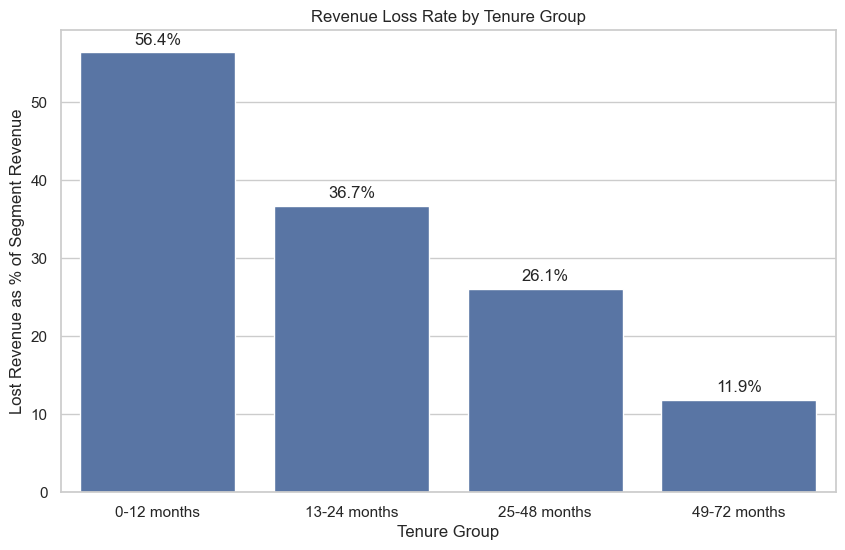

In [24]:
ax = sns.barplot(
    x=tenure_loss_rate.index,
    y=tenure_loss_rate.values
)

plt.title("Revenue Loss Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Lost Revenue as % of Segment Revenue")

for i, value in enumerate(tenure_loss_rate.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

This view shows the financial vulnerability of each tenure stage.

A high revenue loss rate in the first 12 months would confirm that the earliest customer period is both behaviorally and financially the riskiest stage.

## Estimated Customer Lifetime Revenue

A simple way to approximate realized customer value is to compare average `TotalCharges` across active and churned customers.

In [25]:
avg_total_charges_active = active["TotalCharges"].mean()
avg_total_charges_churned = churned["TotalCharges"].mean()

print(f"Average total charges - Active customers: ${avg_total_charges_active:,.2f}")
print(f"Average total charges - Churned customers: ${avg_total_charges_churned:,.2f}")

Average total charges - Active customers: $2,555.34
Average total charges - Churned customers: $1,531.80


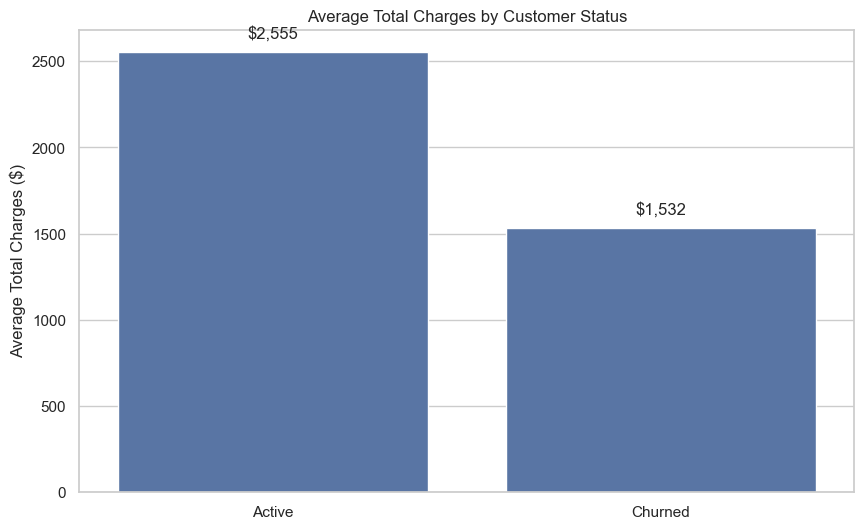

In [26]:
total_charge_comparison = pd.DataFrame({
    "Customer Status": ["Active", "Churned"],
    "Average Total Charges": [avg_total_charges_active, avg_total_charges_churned]
})

ax = sns.barplot(data=total_charge_comparison, x="Customer Status", y="Average Total Charges")
plt.title("Average Total Charges by Customer Status")
plt.xlabel("")
plt.ylabel("Average Total Charges ($)")

for i, value in enumerate(total_charge_comparison["Average Total Charges"]):
    plt.text(i, value + 80, f"${value:,.0f}", ha="center")

plt.show()

This comparison helps show whether churned customers leave before generating as much total revenue as retained customers.

That can indicate unrealized lifetime value and lost long-term monetization opportunity.

## Financial Risk Summary

We now summarize the highest-impact financial segments identified in the analysis.

In [27]:
financial_risk_summary = pd.DataFrame({
    "Segment": [
        "Month-to-month contract",
        "Electronic check",
        "0-12 months tenure"
    ],
    "Lost Monthly Revenue ($)": [
        lost_revenue_by_contract.get("Month-to-month", 0),
        lost_revenue_by_payment.get("Electronic check", 0),
        lost_revenue_by_tenure.get("0-12 months", 0)
    ]
})

financial_risk_summary = financial_risk_summary.sort_values(
    by="Lost Monthly Revenue ($)",
    ascending=False
).reset_index(drop=True)

financial_risk_summary

,Segment,Lost Monthly Revenue ($)
0,Month-to-month contract,120847.10
1,Electronic check,84288.75
2,0-12 months tenure,68954.25


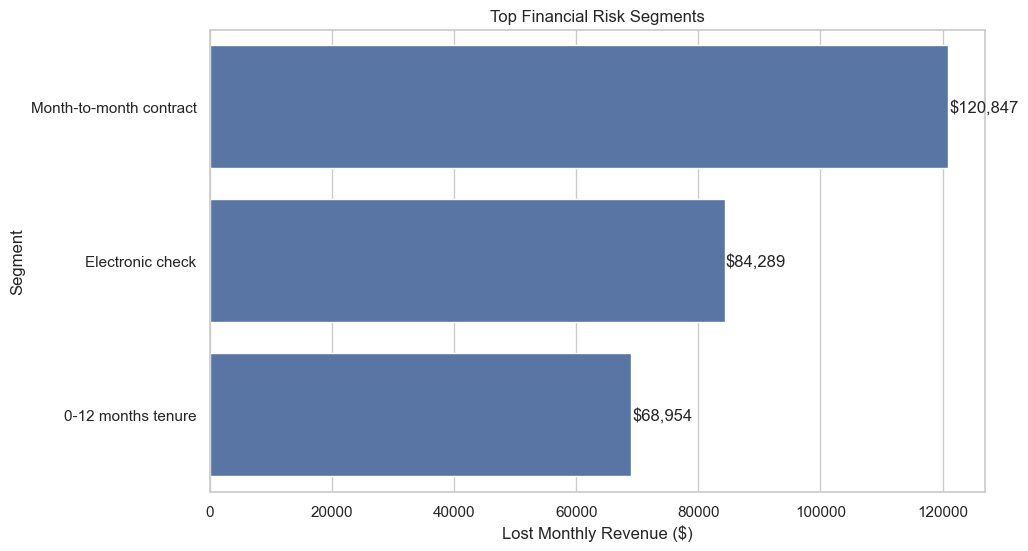

In [28]:
ax = sns.barplot(
    data=financial_risk_summary,
    y="Segment",
    x="Lost Monthly Revenue ($)"
)

plt.title("Top Financial Risk Segments")
plt.xlabel("Lost Monthly Revenue ($)")
plt.ylabel("Segment")

for i, value in enumerate(financial_risk_summary["Lost Monthly Revenue ($)"]):
    plt.text(value + 200, i, f"${value:,.0f}", va="center")

plt.show()

The highest financial risk is concentrated in a small number of customer segments.

This is important because it means retention investments can be more targeted rather than spread equally across the entire customer base.

## Business Impact Scenario

To make the results more practical, we estimate the annual revenue savings if the company reduces churn-related lost monthly revenue by 5%, 10%, and 15%.

In [29]:
impact_scenarios = pd.DataFrame({
    "Reduction in Lost Revenue": ["5%", "10%", "15%"],
    "Estimated Annual Revenue Saved ($)": [
        annualized_lost_revenue * 0.05,
        annualized_lost_revenue * 0.10,
        annualized_lost_revenue * 0.15
    ]
})

impact_scenarios

,Reduction in Lost Revenue,Estimated Annual Revenue Saved ($)
0,5%,83478.51
1,10%,166957.02
2,15%,250435.53


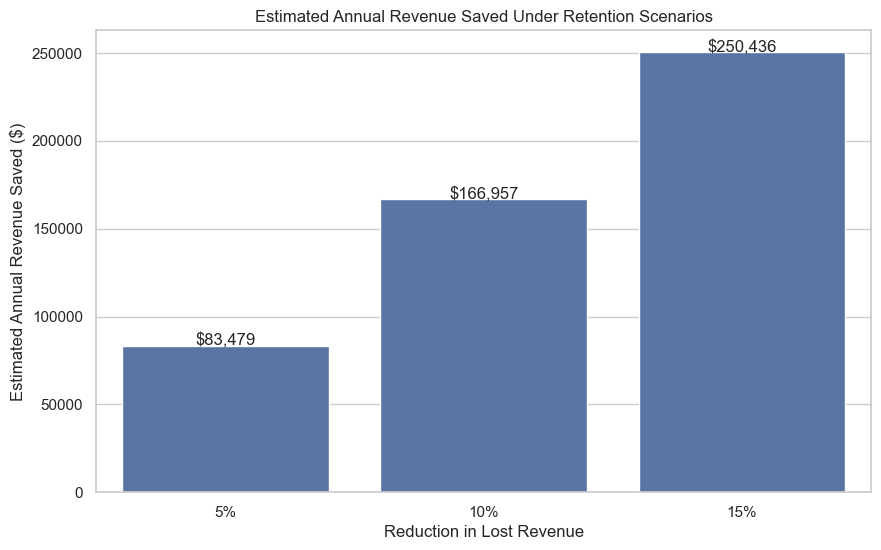

In [30]:
ax = sns.barplot(
    data=impact_scenarios,
    x="Reduction in Lost Revenue",
    y="Estimated Annual Revenue Saved ($)"
)

plt.title("Estimated Annual Revenue Saved Under Retention Scenarios")
plt.xlabel("Reduction in Lost Revenue")
plt.ylabel("Estimated Annual Revenue Saved ($)")

for i, value in enumerate(impact_scenarios["Estimated Annual Revenue Saved ($)"]):
    plt.text(i, value + 500, f"${value:,.0f}", ha="center")

plt.show()

This scenario analysis turns churn into a concrete business case.

It shows that even a modest improvement in retention could generate meaningful annual revenue protection.

## Final Financial Insights

The analysis suggests the following:

1. A meaningful share of monthly revenue is lost due to churn.
2. Churn is financially concentrated in month-to-month customers.
3. Electronic check users represent a costly payment segment.
4. Early-tenure customers create major revenue instability.
5. Revenue protection efforts could produce significant annual savings even with modest retention improvements.

## Conclusion

Customer churn is not only a retention problem but also a direct financial risk.

The company is losing recurring monthly revenue, weakening revenue stability, and reducing the long-term value of acquired customers.

From a financial perspective, the strongest priorities are:

- month-to-month customers
- electronic check users
- customers in their first 12 months

These segments combine high churn exposure with meaningful revenue loss, making them the most valuable targets for retention strategy.